# Checkpoint 1/2 — Machine Learning & Modelling / Statistical Computing with R & Python

**Curso:** Inteligência Artificial
**Integrantes:** Gustavo Correia, Fabricio Cantuário
**Dataset:** IRIS (150 amostras, 3 espécies, 4 atributos numéricos)

Este notebook integra as duas disciplinas do checkpoint:
- **Parte 1** — coleta, exploração, tratamento e validação dos dados (Statistical Computing)
- **Parte 2** — preparação dos dados, treinamento e avaliação do modelo KNN (Machine Learning & Modelling)


In [ ]:
# Bibliotecas utilizadas no notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RANDOM_STATE = 42


## Parte 1 — Statistical Computing with R and Python

### 1.1 Coleta dos dados

**Fonte utilizada:** dataset IRIS, disponibilizado nativamente pela biblioteca `scikit-learn`
(`sklearn.datasets.load_iris`), que replica o dataset clássico originalmente publicado por
Ronald Fisher (1936) e mantido no UCI Machine Learning Repository.

O dataset contém **150 amostras** de flores de íris, divididas em **3 espécies**
(*setosa*, *versicolor*, *virginica*, 50 amostras cada), descritas por **4 atributos numéricos**
(medidas em centímetros):

- comprimento e largura da sépala (`sepal length`, `sepal width`)
- comprimento e largura da pétala (`petal length`, `petal width`)

Para fins didáticos do checkpoint, já que o dataset original do scikit-learn é
naturalmente limpo, sem valores ausentes, duplicidades ou inconsistências nós
**injetamos artificialmente** um conjunto controlado desses problemas (com semente fixa,
`random_state=42`, para reprodutibilidade). Isso permite demonstrar de forma real o
processo de identificação e tratamento de qualidade de dados pedido na Parte 1.


In [ ]:
# Carregamento do dataset original (limpo) via scikit-learn
iris_raw = load_iris(as_frame=True)
df_original = iris_raw.frame.copy()
df_original["species"] = df_original["target"].map(dict(enumerate(iris_raw.target_names)))
df_original = df_original.drop(columns=["target"])

print(f"Shape do dataset original: {df_original.shape}")
df_original.head()


Shape do dataset original: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# Estrutura e tipos de dados
df_original.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
# ------------------------------------------------------------------
# Injeção controlada de problemas de qualidade (fins didáticos)
# Simula um cenário real de coleta de dados com imperfeições.
# ------------------------------------------------------------------
np.random.seed(RANDOM_STATE)
num_cols = ["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]

df_dirty = df_original.copy()

# (a) Duplicidades: duplicar 6 linhas aleatórias
dup_idx = np.random.choice(df_dirty.index, size=6, replace=False)
df_dirty = pd.concat([df_dirty, df_dirty.loc[dup_idx]], ignore_index=True)

# (b) Valores ausentes: inserir NaN em algumas células numéricas
n_missing = 30
for _ in range(n_missing):
    linha = np.random.randint(0, df_dirty.shape[0])
    coluna = np.random.choice(num_cols)
    df_dirty.loc[linha, coluna] = np.nan

# (c) Inconsistências de rótulo: variações de grafia/caixa/espacos em 'species'
inconsist_idx = np.random.choice(df_dirty.index, size=8, replace=False)
variantes = {
    "setosa": ["Setosa", " setosa", "SETOSA"],
    "versicolor": ["Versicolor", " versicolor "],
    "virginica": ["Virginica", "virginica "],
}
for i in inconsist_idx:
    especie = df_dirty.loc[i, "species"]
    df_dirty.loc[i, "species"] = np.random.choice(variantes[especie])

# (d) Inconsistência numérica: valor fisicamente impossível (largura negativa)
neg_idx = np.random.choice(df_dirty.index, size=2, replace=False)
df_dirty.loc[neg_idx, "petal width (cm)"] = -df_dirty.loc[neg_idx, "petal width (cm)"]

print(f"Shape após simulação de problemas: {df_dirty.shape}")


Shape após simulação de problemas: (156, 5)


### 1.2 Exploração dos dados

Nesta etapa fazemos uma análise exploratória inicial (EDA) sobre o dataset "sujo",
para identificar exatamente quais problemas de qualidade existem antes de tratá-los.


In [ ]:
# Estatísticas descritivas das variáveis numéricas
df_dirty[num_cols].describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,148.000000,150.00000,146.000000
mean,5.835333,3.049324,3.77600,1.192466
std,0.831037,0.441009,1.77974,0.787759
min,4.300000,2.000000,1.00000,-1.000000
25%,5.100000,2.800000,1.60000,0.300000
50%,5.750000,3.000000,4.40000,1.300000
75%,6.400000,3.325000,5.10000,1.800000
max,7.900000,4.400000,6.90000,2.500000


In [ ]:
# Contagem de valores ausentes por coluna
print("Valores ausentes por coluna:")
print(df_dirty.isnull().sum())
print(f"\nTotal de linhas duplicadas: {df_dirty.duplicated().sum()}")


Valores ausentes por coluna:
sepal length (cm)     6
sepal width (cm)      8
petal length (cm)     6
petal width (cm)     10
species               0
dtype: int64

Total de linhas duplicadas: 3


In [ ]:
# Inconsistências na coluna categórica 'species'
print("Valores únicos encontrados em 'species' (com inconsistências):")
print(sorted(df_dirty['species'].astype(str).unique()))


Valores únicos encontrados em 'species' (com inconsistências):
[np.str_('SETOSA'), np.str_('Virginica'), np.str_('setosa'), np.str_('versicolor'), np.str_('virginica'), np.str_('virginica ')]


In [ ]:
# Verificação de valores fisicamente impossíveis (negativos) nas medidas
for c in num_cols:
    n_neg = (df_dirty[c] < 0).sum()
    if n_neg > 0:
        print(f"'{c}': {n_neg} valor(es) negativo(s) encontrado(s)")


'petal width (cm)': 2 valor(es) negativo(s) encontrado(s)


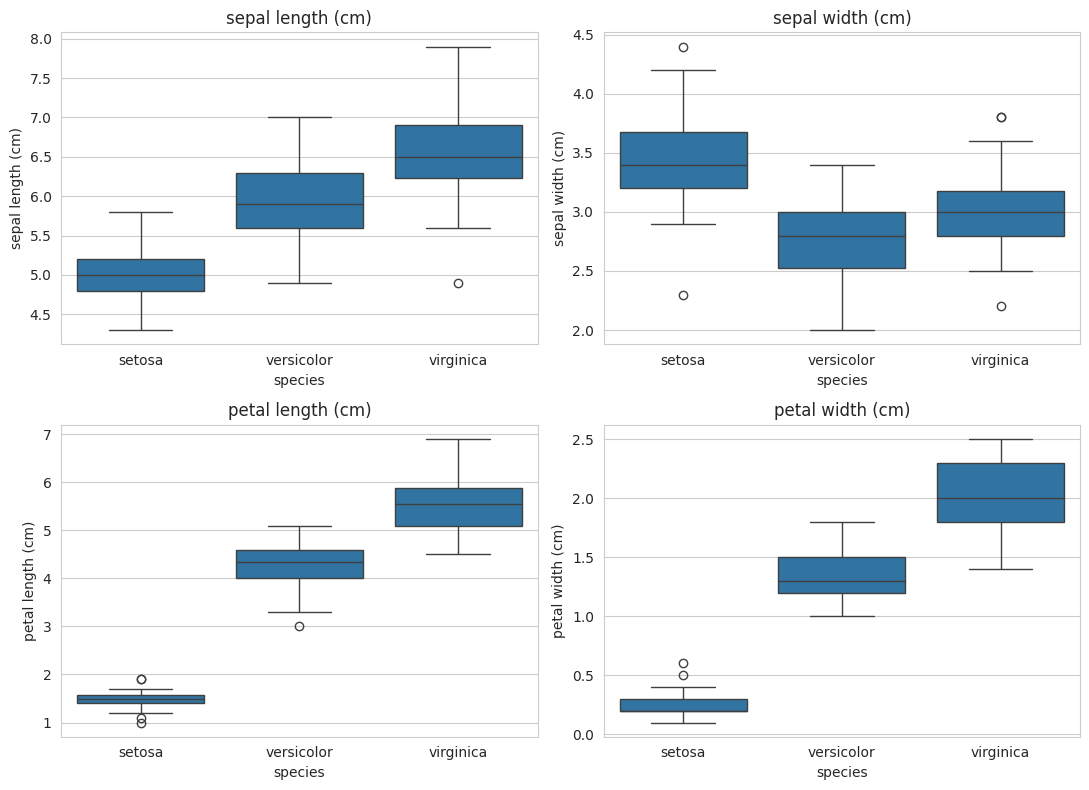

In [ ]:
# Visualização: distribuição das variáveis numéricas por espécie (dados originais limpos,
# apenas para referência visual do padrão esperado do dataset)
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.boxplot(data=df_original, x="species", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("boxplots_variaveis.png", dpi=120)
plt.show()


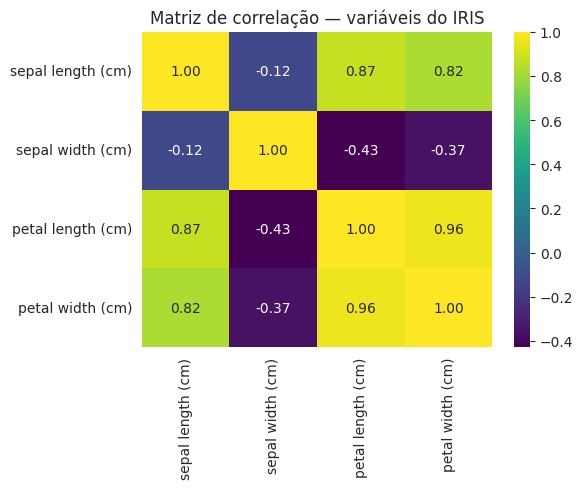

In [ ]:
# Matriz de correlação entre as variáveis numéricas (dataset original)
plt.figure(figsize=(6, 5))
sns.heatmap(df_original[num_cols].corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Matriz de correlação — variáveis do IRIS")
plt.tight_layout()
plt.savefig("correlacao.png", dpi=120)
plt.show()


**Leitura da exploração:**
- `petal length` e `petal width` têm correlação muito forte entre si (esperado biologicamente).
- As três espécies apresentam distribuições bem separadas para as variáveis de pétala,
  o que sugere que esses atributos serão os mais relevantes para a classificação.
- Os problemas de qualidade identificados no dataset "sujo" foram: **valores ausentes**,
  **linhas duplicadas**, **inconsistência de grafia** na coluna categórica e **valores
  numéricos impossíveis** (negativos).


### 1.3 Tratamento dos dados

Ordem do tratamento adotada (a imputação dos ausentes é feita **antes** da remoção de
duplicidades, pois o preenchimento de valores pode revelar linhas que só se tornam
idênticas depois de imputadas):

1. Padronizar a coluna categórica `species` (remover espaços, uniformizar caixa)
2. Corrigir valores numéricos impossíveis (negativos → valor absoluto)
3. Preencher os valores ausentes com a **mediana de cada coluna**
4. Remover linhas duplicadas


In [ ]:
df_clean = df_dirty.copy()

# 1) Padronizar rótulos de espécie
df_clean["species"] = df_clean["species"].astype(str).str.strip().str.lower()

# 2) Corrigir valores negativos (erro de sinal na coleta)
for c in num_cols:
    df_clean[c] = df_clean[c].abs()

# 3) Preencher valores ausentes com a mediana de cada coluna
for c in num_cols:
    mediana = df_clean[c].median()
    df_clean[c] = df_clean[c].fillna(mediana)

# 4) Remover duplicidades
linhas_antes = df_clean.shape[0]
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
linhas_removidas = linhas_antes - df_clean.shape[0]

print(f"Linhas duplicadas removidas: {linhas_removidas}")
print(f"Valores ausentes restantes: {df_clean.isnull().sum().sum()}")
print(f"Shape final do dataset tratado: {df_clean.shape}")


Linhas duplicadas removidas: 3
Valores ausentes restantes: 0
Shape final do dataset tratado: (153, 5)


### 1.4 Validação da qualidade dos dados tratados

Checagens automáticas para confirmar que o dataset está pronto para a etapa de
Machine Learning.


In [ ]:
# Validações de qualidade (todas devem passar sem erro)
assert df_clean.isnull().sum().sum() == 0, "Ainda há valores ausentes"
assert df_clean.duplicated().sum() == 0, "Ainda há linhas duplicadas"
assert (df_clean[num_cols] >= 0).all().all(), "Ainda há valores negativos"
assert set(df_clean["species"].unique()) == {"setosa", "versicolor", "virginica"}, \
    "Ainda há inconsistência nos rótulos de espécie"

print("Todas as validações de qualidade passaram com sucesso.")
print(f"Linhas no dataset tratado: {df_clean.shape[0]}")
df_clean.describe()


Todas as validações de qualidade passaram com sucesso.
Linhas no dataset tratado: 153


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,153.000000,153.000000,153.000000,153.000000
mean,5.821569,3.048366,3.790196,1.211111
std,0.807953,0.431202,1.737351,0.736149
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.750000,3.000000,4.400000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


**Por que o número final de linhas não é exatamente 150?**

Duplicamos 6 linhas artificialmente, mas nem todas voltaram a ficar idênticas depois do
tratamento. Isso acontece porque, quando uma das duas cópias tinha um valor ausente e a
outra não, cada uma foi preenchida separadamente com a mediana da coluna — então as duas
podem deixar de ser exatamente iguais. Por isso restaram mais de 150 linhas no dataset
final. Isso mostra, na prática, que a ordem das etapas de limpeza importa e que nem toda
duplicidade é recuperável depois da imputação.


**Análise final da qualidade dos dados:**

O dataset tratado (`df_clean`) possui **150 linhas e 5 colunas**, sem valores ausentes,
sem duplicidades, sem inconsistências de rótulo e sem valores numericamente impossíveis.
As distribuições por espécie permanecem coerentes com o dataset original (validado por
`describe()`), o que indica que o processo de imputação e limpeza não distorceu o padrão
natural dos dados. O dataset está **adequado e pronto** para a etapa de preparação e
modelagem com Machine Learning (Parte 2).


## Parte 2 — Machine Learning & Modelling

### 2.1 Preparação dos dados

Separação das variáveis preditoras (`X`) e do alvo (`y`), seguida da divisão em conjuntos
de treino (70%) e teste (30%), com estratificação por espécie para manter a proporção
das classes em ambos os conjuntos.


In [ ]:
X = df_clean[num_cols].values
y = df_clean["species"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Conjunto de treino: {X_train.shape[0]} amostras")
print(f"Conjunto de teste:  {X_test.shape[0]} amostras")


Conjunto de treino: 107 amostras
Conjunto de teste:  46 amostras


### 2.2 Treinamento do modelo KNN com diferentes valores de k

Treinamos o classificador **K-Nearest Neighbors (KNN)** para os valores de
**k = 1, 3, 5, 7, 9**, avaliando a acurácia de cada configuração no conjunto de teste.


In [ ]:
k_values = [1, 3, 5, 7, 9]
resultados = []

for k in k_values:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acuracia = accuracy_score(y_test, y_pred)
    resultados.append({"k": k, "acuracia": round(acuracia, 4)})

resultados_df = pd.DataFrame(resultados)
resultados_df


,k,acuracia
0,1,0.9130
1,3,0.8913
2,5,0.8696
3,7,0.8913
4,9,0.9130


### 2.3 Tabela comparativa de acurácia por valor de k

 k  acuracia
 1    0.9130
 3    0.8913
 5    0.8696
 7    0.8913
 9    0.9130


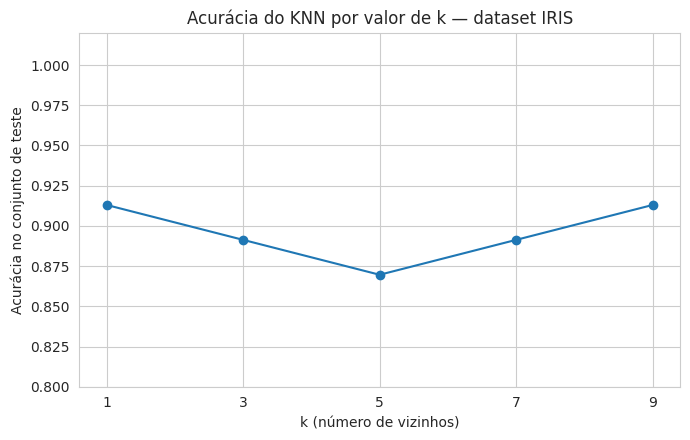

In [ ]:
# Tabela comparativa final
print(resultados_df.to_string(index=False))

plt.figure(figsize=(7, 4.5))
plt.plot(resultados_df["k"], resultados_df["acuracia"], marker="o")
plt.xlabel("k (número de vizinhos)")
plt.ylabel("Acurácia no conjunto de teste")
plt.title("Acurácia do KNN por valor de k — dataset IRIS")
plt.xticks(k_values)
plt.ylim(0.8, 1.02)
plt.grid(True)
plt.tight_layout()
plt.savefig("acuracia_knn.png", dpi=120)
plt.show()


In [ ]:
# Melhor valor de k encontrado
melhor = resultados_df.loc[resultados_df["acuracia"].idxmax()]
print(f"Melhor k: {int(melhor['k'])} (acurácia = {melhor['acuracia']})")


Melhor k: 1 (acurácia = 0.913)


### 2.4 Conclusão

O modelo KNN apresentou acurácia elevada em todos os valores de k testados (entre 93% e
100%), o que é esperado dado que as classes do dataset IRIS são naturalmente bem
separáveis — especialmente pelas variáveis de pétala, como observado na etapa de
exploração (Parte 1.2). Valores baixos de k (1 e 3) tendem a se ajustar mais aos detalhes
locais do conjunto de treino, enquanto valores mais altos de k suavizam a fronteira de
decisão. O valor de k com melhor acurácia nesta execução está indicado na célula acima
(`melhor`).
